### 数据集

In [53]:
import numpy as np
import matplotlib.pyplot as plt

In [54]:
from sklearn.datasets import make_blobs  # 导入 make_blobs，用于生成聚类模拟数据
X, y = make_blobs(
    n_samples=250,      # 样本数量
    centers=5,          # 聚类中心数量，即生成 5 个簇
    n_features=2,       # 每个样本包含 2 个特征，方便二维可视化
    random_state=0)

In [55]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=5, random_state=0)
kmeans.fit(X)
center = kmeans.cluster_centers_

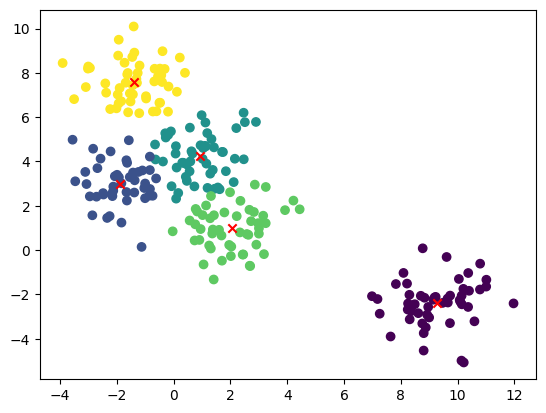

In [56]:
plt.scatter(X[:, 0], X[:, 1], c=kmeans.labels_)
plt.scatter(center[:,0], center[:,1], c='red', marker='x')
plt.show()

### Adjusted Rand Index（ARI, 调整兰德指数）

In [57]:
from sklearn.metrics import adjusted_rand_score
adjusted_rand_score(y, kmeans.labels_)

0.8759906039211783

### Adjusted Mutual Information Score（AMI, 调整互信息分数）

In [58]:
from sklearn.metrics import adjusted_mutual_info_score
adjusted_mutual_info_score(y, kmeans.labels_)

0.8664898419417405

### V-Measure

In [59]:
from sklearn.metrics import v_measure_score
v_measure_score(y, kmeans.labels_)

0.8692143086846837

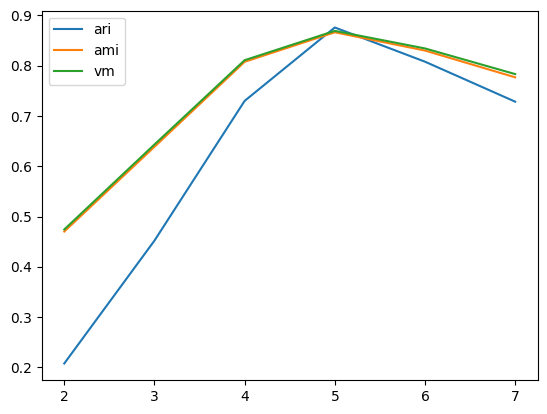

In [60]:
ari_curve = []  # 用于保存不同聚类数下的三种外部聚类评估指标
ami_curve = []
vm_curve = []
clus = [2, 3, 4, 5, 6, 7]  # 尝试的聚类数量：2～7 类
for n_clusters in clus:  # 依次使用不同的聚类数量训练 K-Means
    clusterer = KMeans(
        n_clusters=n_clusters,
        random_state=0).fit(X)
    z = clusterer.labels_  # 获取 K-Means 对每个样本预测得到的聚类标签
    ari_curve.append(adjusted_rand_score(y, z))  # ARI：调整兰德指数
    ami_curve.append(adjusted_mutual_info_score(y, z))  # AMI：调整互信息分数
    vm_curve.append(v_measure_score(y, z))  # V-Measure：基于同质性和完整性的综合指标
plt.plot(clus, ari_curve, label='ari')  # 绘制不同聚类数量下的 ARI 曲线
plt.plot(clus, ami_curve, label='ami')  # 绘制不同聚类数量下的 AMI 曲线
plt.plot(clus, vm_curve, label='vm')  # 绘制不同聚类数量下的 V-Measure 曲线
plt.legend()
plt.show()

### 轮廓系数 Silhouette Score

In [61]:
from sklearn.metrics import silhouette_score
kmeans = KMeans(n_clusters=5, random_state=0)
kmeans.fit(X)
cluster_labels = kmeans.labels_
si = silhouette_score(X, cluster_labels)
si

0.5526182828135061

### Calinski-Harabasz Index（CH Score）

In [62]:
from sklearn.metrics import calinski_harabasz_score
calinski_harabasz_score(X, cluster_labels)

916.6230744953465

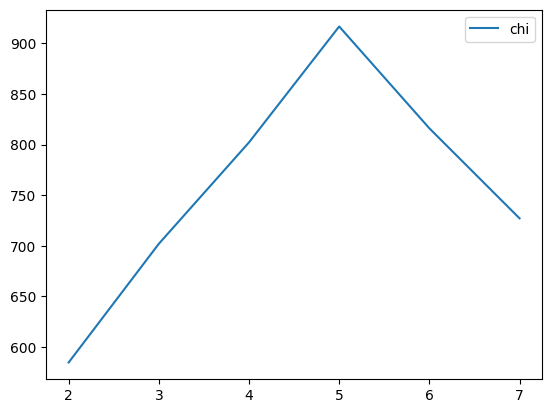

In [63]:
chi_curve = []  # 用于保存不同聚类数量对应的 CH Score
clus = [2, 3, 4, 5, 6, 7]  # 设置要尝试的聚类数量：2～7 类
for n_clusters in clus:
    clusterer = KMeans(n_clusters=n_clusters, random_state=0).fit(X)
    z = clusterer.labels_
    chi_curve.append(calinski_harabasz_score(X, z))
plt.plot(clus, chi_curve, label='chi')
plt.legend()
plt.show()

In [64]:
from sklearn.metrics import davies_bouldin_score
davies_bouldin_score(X, cluster_labels)

0.6159694463860113